# Calibration against SST data

Contains comparision of model output and ODYSSEA satellite data of sea surface temperature by calculating metrics and plotting data.

In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
from pathlib import Path
import sys

# Project root
PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

from modules import metrics
from modules import read_files as read
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import glob
import h5py

### Configuration

In [99]:
dir_odyssea = '../../data/calibration/odyssea_test.nc'
dir_model = '../../data/calibration/nested_v4_test/L1/WaterProperties_1_interp.hdf5'
outdir = '../../data/calibration/nested_v4_test/L1//'

### Read data and convert model output files to netcdf

In [100]:
# read satellite data
ds_odyssea = xr.open_dataset(dir_odyssea)
ds_odyssea['sst'] = ds_odyssea['analysed_sst'] - 273.15  # convert to celcius degrees
ds_odyssea

<xarray.Dataset> Size: 202kB
Dimensions:           (time: 1, latitude: 89, longitude: 113)
Coordinates:
  * time              (time) datetime64[ns] 8B 2023-02-23
  * latitude          (latitude) float32 356B 27.21 27.23 27.25 ... 28.95 28.97
  * longitude         (longitude) float32 452B -17.83 -17.81 ... -15.61 -15.59
Data variables:
    analysed_sst      (time, latitude, longitude) float32 40kB 292.6 ... 292.5
    analysis_error    (time, latitude, longitude) float32 40kB ...
    mask              (time, latitude, longitude) float32 40kB ...
    sea_ice_fraction  (time, latitude, longitude) float32 40kB ...
    sst               (time, latitude, longitude) float32 40kB 19.5 ... 19.33
Attributes:
    Conventions:       CF-1.11
    title:             ODYSSEA North-East Atlantic Sea Surface Temperature Gr...
    institution:       Institut Francais de Recherche pour l'Exploitation de ...
    source:            Odyssea L4 processor
    history:           Optimally interpolated SST originally produced by Ifre...
    contact:           emmanuelle.autret@ifremer.fr;jfpiolle@ifremer.fr
    references:        Product User Manual for L4 Odyssea Product over the No...
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  SST_ATL_SST_L4_NRT_OBSERVATIONS_010_025
    subset:datasetId:  IFREMER-ATL-SST-L4-NRT-OBS_FULL_TIME_SERIE_201904
    subset:date:       2026-08-05T10:28:23.381Z

In [ ]:
# read and convert model output files
t, dates = read.MOHIDHdf5toNetcdf(dir_model, outdir=outdir)

# concat files with time
files = sorted(glob.glob(r'C:\Users\karoa\MOHID_internship\MOHID_model_workflow\data\calibration\nested_v4_test\L1\WaterProperties_*.nc'))
datasets = [xr.open_dataset(f) for f in files]

# Stack them along a 'time' dimension
ds = xr.concat(datasets, dim='time')

# Close the underlying file handles now that data is in memory
for d in datasets:
    d.close()

# assign coordinate according to dates
with h5py.File(dir_model, 'r') as f:
    time_keys = sorted(f['Time'].keys())
    real_dates = []
    for k in time_keys:
        arr = f['Time'][k][:].ravel().astype(float)  
        y, m, d, H, M, S = arr[:6]
        real_dates.append(pd.Timestamp(int(y), int(m), int(d),
                                       int(H), int(M), int(round(S))))

ds = ds.assign_coords(time=('time', real_dates))

# remove fill values
ds = ds.where(ds.temperature > 0, drop=True)

# average to daily
ds = ds.resample(time='1D').mean() 

# rename coordinates
ds = ds.rename({'lat':'latitude'})
ds = ds.rename({'lon':'longitude'})

# interpolate model output to satellite data
ds = ds.interp(latitude=ds_odyssea.latitude, longitude=ds_odyssea.longitude)

ds

<xarray.Dataset> Size: 242kB
Dimensions:      (time: 3, latitude: 89, longitude: 113)
Coordinates:
  * time         (time) datetime64[us] 24B 2023-02-21 2023-02-22 2023-02-23
  * latitude     (latitude) float32 356B 27.21 27.23 27.25 ... 28.93 28.95 28.97
  * longitude    (longitude) float32 452B -17.83 -17.81 -17.79 ... -15.61 -15.59
Data variables:
    temperature  (time, latitude, longitude) float32 121kB nan nan ... nan nan
    Bathymetry   (time, latitude, longitude) float32 121kB nan nan ... nan nan

### Compare

In [213]:
# Calculate metrics
temp = ds["temperature"]
sst = ds_odyssea["sst"]

# Keep only locations where both datasets have valid values
valid = temp.notnull() & sst.notnull()

temp_valid = temp.where(valid, drop=True)
sst_valid = sst.where(valid, drop=True)

rmse = metrics.rmse(temp_valid, sst_valid).mean()
bias = metrics.bias(temp_valid, sst_valid).mean()

print('RMSE:', rmse.item())
print('Bias:', bias.item())

RMSE: 0.22498328983783722
Bias: 0.223479226231575


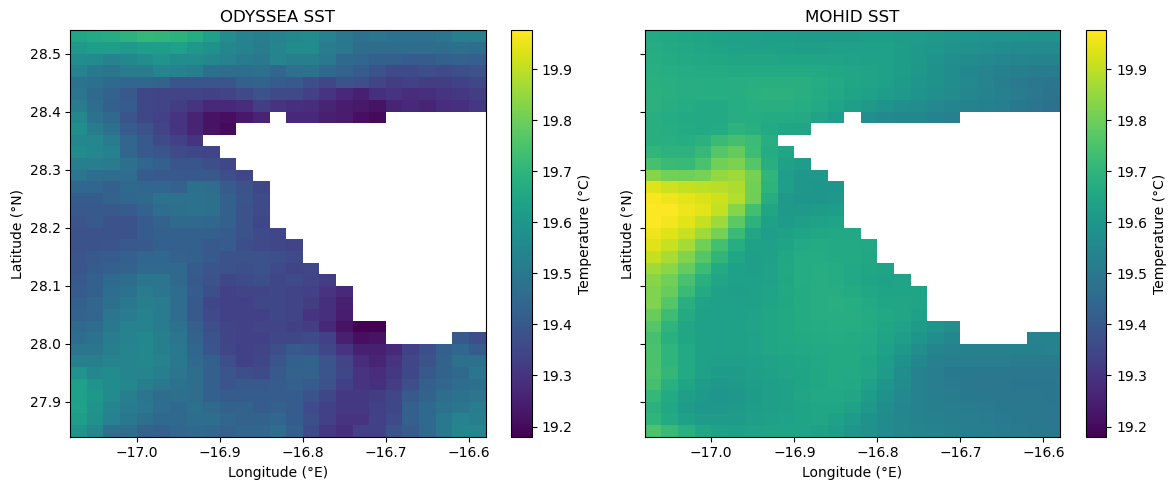

In [172]:
# visualize data
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# make sure color limits are same
vmin = min(
    ds_odyssea['sst'].where(valid).min().item(),
    ds['temperature'].where(valid).min().item()
)
vmax = max(
    ds_odyssea['sst'].where(valid).max().item(),
    ds['temperature'].where(valid).max().item()
)

ds_odyssea['sst'].where(valid).plot(
    ax=axes[0],
    vmin=vmin,
    vmax=vmax,
    cbar_kwargs={'label': 'Temperature (°C)'}
)
axes[0].set_title("ODYSSEA SST")


ds['temperature'].where(valid).plot(
    ax=axes[1],
    vmin=vmin,
    vmax=vmax,
    cbar_kwargs={'label': 'Temperature (°C)'}
)
axes[1].set_title("MOHID SST")

# Common axis settings
for ax in axes:
    ax.set_xlim(-17.08, -16.58)
    ax.set_ylim(27.84, 28.54)
    ax.set_xlabel("Longitude (°E)")
    ax.set_ylabel("Latitude (°N)")


plt.tight_layout()
plt.show()